[![logo](https://climate.copernicus.eu/sites/default/files/custom-uploads/branding/LogoLine_horizon_C3S.png)](https://climate.copernicus.eu)

# Storm Daria: a Step-by-Step Guide to Windstorm Analysis 

## Introduction 

The following use case illustrates the capabilities and potential of the Enhanced Windstorm Service (EWS) by walking through the steps of a concrete analysis, from data access to the plots of interest to the user.
The analysis aims to identify a known event within the EWS dataset, compare its footprint with available observations, and place this single event in perspective relative to all other storms in the EWS dataset affecting a given region.

### Datasets used in this notebook

In this notebook, the following datasets will be used: 
- Windstorm tracks;
- Windstorm footprints; 
- Station-scale wind gust observations from the HadlSD dataset.

Further dataset-related information can be found in the Product User Guide: https://confluence.ecmwf.int/display/CKB/Windstorm+tracks+and+footprints+derived+from+reanalysis+over+Europe+between+1940+to+present%3A+Product+User+Guide

## Storm of interest

The Storm we are focusing on is Storm Daria, which was an extremely violent windstorm that took place on 25–26 January 1990 over North-Western Europe. It is one of the strongest European windstorms on record, and it caused many fatalities in the UK and Europe. 
The storm, also known as Burn’s Day Storm, began as a cold front over the Northern Atlantic Ocean on 23 January. By 24 January, it had a minimum central pressure of 992 millibars and began to undergo explosive cyclogenesis. It made landfall on the morning of January 25 over Ireland. It then tracked over to Ayrshire in Scotland. The lowest pressure of 949 mbar was estimated near Edinburgh around 16:00. After hitting the United Kingdom, the storm tracked rapidly east towards Denmark, causing major damage and a further 30 deaths in the Netherlands and Belgium.
Casualties were much higher than those of the Great Storm of 1987 because the storm hit during the daytime. There were 47 deaths in the UK, most caused by collapsing buildings or falling debris. A further 21 casualties were reported across France, Belgium and the Netherlands. The storm caused extensive damage, with approximately 3 million trees downed, power disrupted to over 500,000 homes and severe flooding in England and West Germany. The storm cost insurers in the UK £3.37 billion, the UK's most expensive weather event for insurers. The overall cost, is estimated Swiss Re is over 6 billion euros.


## Learning objectives 🎯

The present use case shows how to analyse a single storm event using the Enhanced Windstorm Service (EWS) dataset. The analysis is broken down into the three steps listed above, each one being broken down into three operations:

- Download: where download functions are defined to retrieve the relevant data
- Processing: where processing functions are defined, particularly to identify a specific track amongst all the EWS events
- Plotting: where plotting functions are defined to create the output plots of the analysis.

## Prepare your environment

To run the present notebook we advise to create a dedicated `conda` environment.

Provided you have conda installed you only need to run:

```sh
conda create -n use_case_01 -c conda-forge aiohttp cartopy cdsapi cf_xarray dask fsspec geopandas ipykernel jupyterlab pandas tqdm netcdf4 regionmask requests xarray
```

### Setup the CDSAPI and your credentials

In [1]:
# If you have already setup your .cdsapirc file you can leave this as None
cdsapi_key = None
cdsapi_url = None

### Import libraries

Once you have activated the environment and opened the notebook you can run the following imports.

In [2]:
import gzip
import shutil
import tarfile
import tempfile
import urllib.parse
import zipfile
from pathlib import Path
from typing import Any, Literal

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import fsspec
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import regionmask
import tqdm
import xarray as xr
from cartopy.mpl.geoaxes import GeoAxes
from cdsapi import Client
from matplotlib import patheffects

### Specify data directory

Before defining any specific function let us define the local and analysis specific settings.

First define the local folders where you want to save the downloaded storm tracks (`c3s_windstorm_path`), observations (`hadisd_path`) and nuts shapefiles (`nuts_path`).

**These folders need to be set for the notebook to be run on your own machine.**

In [3]:
# Local folders for data download
c3s_windstorm_path = Path("/private1/v1_0")
hadisd_path = Path("/private1/hadisd")
nuts_path = Path("/private1/NUTS_RG_20M_2021_4326.shp.zip")

### Specify parameters

Define the characteristics of your storm of interest:

- `central_time` is a time stamp characterising the storm. The identification algorithm will look for the EWS track with the central time closest to this input.

- `name` is a string used to label the plots and can be personalised. It does not need to match any know storm.

You can run the notebook without changing this default input; we recommend to do so if you run the notebook for the first time.

In [4]:
# Storm
central_time = "25-01-1990"
name = "Daria"

Choose the tracking algorithm to use for the comparison against observations (Step 2) and the historical storm time series (Step 3):

- `algorithm` is the name of the tracking algorithm. It can be either `tempest_extremes` or `hodges`. You can run the notebook without changing this input.

In [5]:
# Algorithm
algorithm = "tempest_extremes"

Choose the region of interest:

- `region` is the NUTS code of the region you want to focus on. NUTS 0, 1 and 2 codes can be chosen. You can run the notebook without changing this input.

In [6]:
# Region
region = "UK"

Choose wether to download only essential data:

- `minimal_download` can be either `True` or `False`. When set to `False`, the mean wind gust of each detected storm is included in Figure 3.

In [7]:
minimal_download = True

Change the dimensions and characteristics of the plots. You can run the notebook without changing this input.

In [8]:
# Plots
plt.style.use("seaborn-v0_8-notebook")
small_figsize = (15, 6)
large_figsize = (15, 10)
extent = (-15, 20, 36, 65)
projection = ccrs.PlateCarree()
footprint_kwargs = {
    "transform": ccrs.PlateCarree(),
    "cmap": "gist_ncar",
    "vmin": 15,
    "vmax": 50,
    "extend": "both",
}
bias_kwargs = {
    "transform": ccrs.PlateCarree(),
    "x": "longitude",
    "y": "latitude",
    "hue": "wind_gust_bias",
    "cmap": "RdBu_r",
    "vmin": -20,
    "vmax": 20,
    "extend": "both",
    "add_legend": False,
}
scatter_kwargs = {
    "x": "year",
    "y": "decontaminated_footprint",
    "edgecolor": "k",
}

Function adding cartografical features to geospatial plots such as a CCRS, coastlines and borders. You can run the notebook without changing this function.

In [9]:
def postprocess_ax(
    ax: GeoAxes,
    track: pd.DataFrame,
    extent: tuple[int, int, int, int],
) -> None:
    track.plot(
        x="longitude",
        y="latitude",
        ax=ax,
        transform=ccrs.PlateCarree(),
        color="k",
        path_effects=[
            patheffects.Stroke(linewidth=5, foreground="w"),
            patheffects.Normal(),
        ],
        legend=False,
    )
    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.add_feature(cfeature.BORDERS, linewidth=1)
    ax.set_extent(extent)

## Step 1: storm identification

To analyse this single event in the light of the EWS dataset, the first step is to identify the storm amongst the available tracks and footprints. The code underlying the use case defines a function allowing to identification of the EWS track which is closest to a given event. The criteria used to identify an event are the central time of the event.
For storm Daria,  the central time considered is the 25th of January 1990. The identification function yielded two outputs, one for Tempest Extremes and another for the Hodges (TRACK) algorithm.
In this step, we download the EWS dataset and identify the tracks matching the storm of interest and characterised by the `central_time` defined in the Settings above.

Once the track IDs are identified (one for Tempest Extremes and one for Hodges), the corresponding footprints are opened and plotted.

### Download

This function downloads all the track and footprints of the EWS dataset and saves them in the `c3s_windstorm_path` folder.

In [10]:
def robust_retrieve(
    client: Client, dataset: str, request: dict[str, Any], path: Path
) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with tempfile.NamedTemporaryFile(dir=path.parent, suffix=".zip") as tmpfile:
        client.retrieve(dataset, request, tmpfile.name)
        with tempfile.TemporaryDirectory(dir=path.parent) as tmpdir:
            with zipfile.ZipFile(tmpfile.name, "r") as zip_ref:
                zip_ref.extractall(tmpdir)
            Path(tmpdir).rename(path)
    assert path.exists()


def download_aggregated(client: Client, path: Path) -> Path:
    dataset = "sis-european-wind-storm-reanalysis"
    collection = client.client.get_collection(dataset)
    updated_at = collection.updated_at.strftime("%Y-%m-%d")

    all_path = path / "all" / updated_at
    for product in tqdm.tqdm(
        ["windstorm_track", "windstorm_summary_indicator"],
        desc="Downloading aggregated events",
    ):
        request = {
            "product": product,
            "variable": "all",
            "tracking_algorithm": ["hodges", "tempestextremes"],
            "_no_cache": updated_at,
        }
        if product == "windstorm_track":
            request["event_aggregation"] = "all_events"

        target_path = all_path / product
        if not target_path.exists():
            robust_retrieve(client, dataset, request, target_path)
    return all_path


def download_footprints(df: pd.DataFrame, client: Client, path: Path) -> None:
    dataset = "sis-european-wind-storm-reanalysis"
    request = {
        "product": "windstorm_footprint",
        "variable": "all",
        "event_aggregation": "single_event",
        "windstorm_footprint_resolution": ["downscaled", "original"],
        "spatial_extent": ["full_domain", "windstorm_footprint_area"],
    }
    for (_, algorithm), df_track in tqdm.tqdm(
        df.groupby(["id", "algorithm"]),
        desc="Downloading footprints",
    ):
        date = df_track["time"].min()
        request.update(
            {
                "tracking_algorithm": [algorithm.replace("_", "")],
                "year": [date.strftime("%Y")],
                "month": [date.strftime("%m")],
                "day": [date.strftime("%d")],
            }
        )
        target_path = path / "single" / algorithm / date.strftime("%Y-%m-%d")
        if not target_path.exists():
            robust_retrieve(client, dataset, request, target_path)


def download_c3s_windstorm(
    path: Path,
    start: str | None = None,
    end: str | None = None,
    cdsapi_key: str | None = None,
    cdsapi_url: str | None = None,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    path.mkdir(exist_ok=True, parents=True)
    client = Client(key=cdsapi_key, url=cdsapi_url, quiet=True)

    all_path = download_aggregated(client, path)
    all_tracks = pd.concat(
        [
            pd.read_csv(p, parse_dates=["time"])
            for p in (all_path / "windstorm_track").iterdir()
        ]
    )
    all_indicators = pd.concat(
        [pd.read_csv(p) for p in (all_path / "windstorm_summary_indicator").iterdir()]
    )

    if start is not None:
        all_tracks = all_tracks[all_tracks["time"] >= pd.to_datetime(start)]
    if end is not None:
        all_tracks = all_tracks[all_tracks["time"] <= pd.to_datetime(end)]

    download_footprints(all_tracks, client, path)
    return all_tracks, all_indicators

In [11]:
if minimal_download:
    dtime = pd.to_datetime(central_time, dayfirst=True)
    offset = pd.DateOffset(months=1)
    start = (dtime - offset).strftime("%Y-%m")
    end = (dtime + offset).strftime("%Y-%m")
else:
    start = None
    end = None
# Launch the download of the EWS dataset
all_tracks, all_indicators = download_c3s_windstorm(
    c3s_windstorm_path,
    start=start,
    end=end,
    cdsapi_key=cdsapi_key,
    cdsapi_url=cdsapi_url,
)

2025-06-25 07:22:43,242 WARNING [2025-06-23T00:00:00] Scheduled System Session affecting Service reliability - 30 June 2025. Please follow status [here](https://status.ecmwf.int/) or in our [forum](https://forum.ecmwf.int/t/scheduled-maintenance-of-the-cloud-infrastructure-on-30-june-2025/13598)


### Processing

The functions defined below allow respectively to identify the track id that is closest to the storm event that you are looking for and to retrieve the footprints corresponding to these ids.
The identification is performed for both tracking algorithms in order to compare the tracks identified by both algorithms.

In [12]:
# Return the ids of the track closest to the `central_time` setting
def find_track_ids(
    data_path: Path,
    central_time: str,
) -> dict[str, int]:
    track_ids = {}
    for algorithm in tqdm.tqdm(["tempest_extremes", "hodges"], desc="Finding track ID"):
        central_times = (
            xr.open_mfdataset(
                str(
                    data_path
                    / "single"
                    / algorithm
                    / "*-*-*"
                    / f"storm_footprint-{algorithm}-*-original-decontaminated-*.nc"
                )
            )["footprint_central_time"]
            .swap_dims(track_id="footprint_central_time")
            .sortby("footprint_central_time")
            .compute()
        )
        ids = {
            central_times.drop_duplicates("footprint_central_time", keep=keep)
            .sel(footprint_central_time=central_time, method="nearest")["track_id"]
            .item()
            for keep in ("first", "last")
        }
        if len(ids) > 1:
            raise ValueError(f"Multiple tracks found: {algorithm=} {ids=}")
        (track_ids[algorithm],) = ids
    return track_ids


# Open a footprint for a given algorithm, resolution and track id
def open_footprints(
    data_path: Path,
    algorithm: Literal["hodges", "tempest_extremes"],
    resolution: Literal["original", "downscaled"],
    field: Literal["full", "decontaminated"],
    track_id: int | None = None,
) -> xr.DataArray:
    track_id = f"{'*' if track_id is None else track_id}"
    path = str(
        data_path
        / "single"
        / algorithm
        / "*-*-*"
        / f"storm_footprint-{algorithm}-*-{track_id}-{resolution}-{field}*.nc"
    )
    (da,) = xr.open_mfdataset(path).data_vars.values()
    return da


# Open a footprint of each algorithm for a given resolution and track id
def open_footprints_for_comparison(
    data_path: Path,
    resolution: Literal["original", "downscaled"],
    track_ids: dict[str, int],
) -> xr.DataArray:
    dataarrays = []
    for algorithm, track_id in tqdm.tqdm(track_ids.items(), desc="Opening footprint"):
        da = open_footprints(
            data_path, algorithm, resolution, "decontaminated", track_id
        )
        dataarrays.append(da.squeeze("track_id").expand_dims(algorithm=[algorithm]))
    return xr.concat(dataarrays, "algorithm")


# Open EWS storm tracks
def open_tracks(df: pd.DataFrame, track_ids: dict[str, int]) -> pd.DataFrame:
    return pd.concat(
        [
            df[(df["algorithm"] == algorithm) & (df["id"] == track_id)]
            for algorithm, track_id in track_ids.items()
        ]
    )

In this step the relevant track corresponding to the storm of interest are identified and the corresponding tracks and footprints opened.

These tracks and footprint will then be plotted for comparison in Figure 1.

In [13]:
track_ids = find_track_ids(c3s_windstorm_path, central_time)
tracks = open_tracks(all_tracks, track_ids)
footprints_for_comparison = open_footprints_for_comparison(
    c3s_windstorm_path,
    "original",
    track_ids,
)

Opening footprint: 100%|██████████| 2/2 [00:00<00:00, 81.32it/s]


### Figure 1

Figure 1 shows a plot of the identified storm track and footprint. This latter is defined as the maximum 10m-height wind gust at each grid point in the domain over a 72-hour time window. For both algorithms, the storm tracks correspond to the low-pressure trajectory described above (Ireland, Scotland and Denmark) while the footprints show the high winds that affected the south of the UK, the north of France, Belgium and the Netherlands.

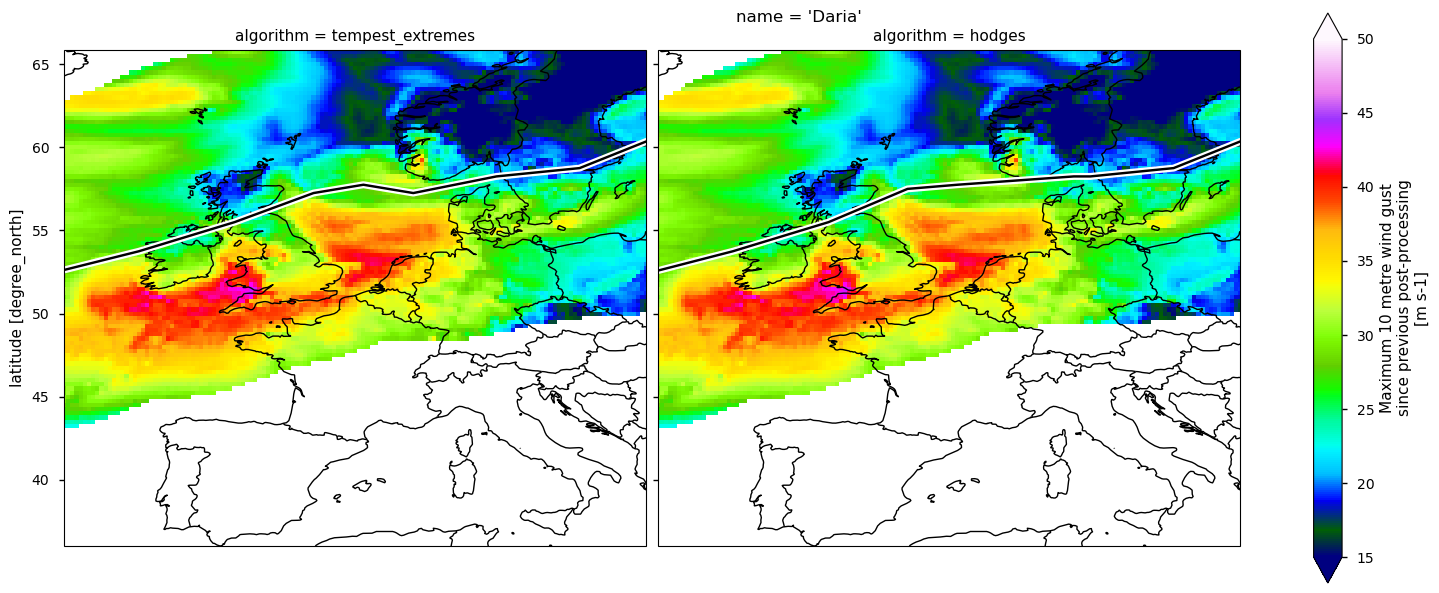

In [14]:
facet = footprints_for_comparison.plot(
    col="algorithm",
    subplot_kws={"projection": projection},
    figsize=small_figsize,
    **footprint_kwargs,
)
for ax, sel in zip(facet.axs.flatten(), facet.name_dicts.flatten()):
    postprocess_ax(ax, tracks[tracks["algorithm"] == sel["algorithm"]], extent)
_ = facet.fig.suptitle(f"{name = }")

## Step 2: comparison with observation data

For each identified storm event, the EWS catalogue entry contains a track and a footprint. The footprint is available in four versions:
- Original
- Original decontaminated
- Downscaled
- Downscaled decontaminated

For an in-depth analysis of on-land effects of a storm, the downscaled and decontaminated footprint is the most suitable footprint as it provides the highest resolution and takes into account the topography. To evaluate the validity of a given downscaled footprint, it can be compared to wind measurements coming from weather stations. The  reference dataset considered, providing quality-controlled sub-daily wind gust observations, is the HadISD.
The code underlying the present use case contains functions allowing for to fetch of the relevant data from the HadlSD dataset and comparing it to a given EWS footprint. To compare the EWS footprint with the observations, the approach is to consider the maximum wind speed measured at the weather stations within the time frame of the storm. This maximum value is then compared to the wind speed value of the EWS footprint. In the figure below, we observe original resolution and downscaled footprint (upper and bottom panels respectively), wind gust physical values (left panels) and the associated biases in correspondence of grid points nearest to the observational sites (right panels). 

### Download

This function saves the HadISD observation dataset in the `hadisd_path` folder.

In [15]:
def download_hadisd(path: Path) -> None:
    base_url = "https://www.metoffice.gov.uk/hadobs/hadisd/v341_202410p/"
    info_name = "hadisd_station_info_v341_202410p.txt"
    data_names = (
        "WMO_000000-029999.tar.gz",
        "WMO_030000-049999.tar.gz",
        "WMO_050000-079999.tar.gz",
        "WMO_080000-099999.tar.gz",
        "WMO_100000-149999.tar.gz",
        "WMO_150000-199999.tar.gz",
        "WMO_200000-249999.tar.gz",
        "WMO_250000-299999.tar.gz",
        "WMO_300000-349999.tar.gz",
        "WMO_350000-399999.tar.gz",
        "WMO_400000-449999.tar.gz",
        "WMO_450000-499999.tar.gz",
        "WMO_500000-549999.tar.gz",
        "WMO_550000-599999.tar.gz",
        "WMO_600000-649999.tar.gz",
        "WMO_650000-699999.tar.gz",
        "WMO_700000-709999.tar.gz",
        "WMO_710000-714999.tar.gz",
        "WMO_715000-719999.tar.gz",
        "WMO_720000-721999.tar.gz",
        "WMO_722000-722999.tar.gz",
        "WMO_723000-723999.tar.gz",
        "WMO_724000-724999.tar.gz",
        "WMO_725000-725999.tar.gz",
        "WMO_726000-726999.tar.gz",
        "WMO_727000-729999.tar.gz",
        "WMO_730000-799999.tar.gz",
        "WMO_800000-849999.tar.gz",
        "WMO_850000-899999.tar.gz",
        "WMO_900000-949999.tar.gz",
        "WMO_950000-999999.tar.gz",
    )
    path.mkdir(parents=True, exist_ok=True)

    fs = fsspec.filesystem("https")
    info_path = path / info_name
    if not info_path.exists():
        fs.get_file(urllib.parse.urljoin(base_url, f"files/{info_name}"), info_path)

    with tempfile.TemporaryDirectory(dir=path) as tmp_dir:
        for name in tqdm.tqdm(data_names, desc=f"Downloading {base_url}"):
            permanent_path = path / name.replace(".tar.gz", "")
            if permanent_path.exists():
                continue

            temporary_path = Path(tmp_dir) / permanent_path.name
            url = urllib.parse.urljoin(base_url, f"data/{name}")
            with fs.open(url, mode="rb") as fp:
                with tarfile.open(fileobj=fp, mode="r:gz") as tar:
                    tar.extractall(path=temporary_path, filter="data")

            for gz_path in temporary_path.glob("*.gz"):
                with (
                    gzip.open(gz_path, "rb") as f_in,
                    gz_path.with_suffix("").open("wb") as f_out,
                ):
                    shutil.copyfileobj(f_in, f_out)
                gz_path.unlink()

            temporary_path.rename(permanent_path)

In [16]:
# Launch the HadISD observation dataset download
download_hadisd(hadisd_path)

### Processing

These functions respectively open the HadISD station data and compute the bias of a given footprint against the observed data in the relevant time frame.

In [17]:
# Open HadISD station data
def open_station(
    data_path: Path,
    station_id: str,
) -> xr.Dataset:
    (path,) = data_path.glob(f"**/*_{station_id}.nc")
    ds = xr.open_dataset(path, chunks={})
    ds["station_id"] = ds["station_id"].expand_dims("coordinate_length")
    return ds.swap_dims(coordinate_length="station_id")


# Computes the bias between a given footprint and the HadISD station observations
def compute_stations_bias(
    data_path: Path,
    footprint: xr.DataArray,
    track: pd.DataFrame,
) -> xr.DataArray:
    # Filter stations
    (stations_path,) = data_path.glob("*.txt")
    stations = pd.read_csv(
        stations_path,
        names=["id", "latitude", "longitude", "elevation"],
        header=None,
        delimiter=r"\s+",
    )
    cutout = footprint.dropna("latitude", how="all").dropna("longitude", how="all")
    mask = (
        (stations["latitude"] >= cutout["latitude"].min().item())
        & (stations["latitude"] <= cutout["latitude"].max().item())
        & (stations["longitude"] >= cutout["longitude"].min().item())
        & (stations["longitude"] <= cutout["longitude"].max().item())
    )
    filtered_stations = stations[mask]

    # Loop over stations
    start = track["time"].min()
    end = track["time"].max()
    dataarrays = []
    for station_id in tqdm.tqdm(
        set(filtered_stations["id"]), desc="Computing station bias"
    ):
        ds = open_station(data_path, station_id)
        da_obs = ds["wind_gust"].expand_dims("station_id").assign_coords(ds.coords)

        # Time filter
        da_obs = da_obs.sel(time=slice(start, end))
        if not da_obs.sizes["time"]:
            continue

        # Select point
        da_obs = da_obs.max("time", keep_attrs=True)
        da_tracks = footprint.sel(
            latitude=da_obs["latitude"],
            longitude=da_obs["longitude"],
            method="nearest",
        )
        if da_tracks.isnull().all():
            continue

        # Compute bias
        with xr.set_options(keep_attrs=True):
            da_bias = (da_tracks - da_obs).assign_coords(da_obs.coords)
        da_bias.attrs["long_name"] = "Bias of " + da_bias.attrs["long_name"]
        dataarrays.append(da_bias)
    return xr.concat(dataarrays, "station_id").rename("wind_gust_bias").compute()

This cell retrieves the footprints to be compared to the observation data and computes the bias against the HadISD stations.

These biases and footprint are then plotted in Figure 2.

In [18]:
track = tracks[tracks["algorithm"] == algorithm]
footprints_for_bias = {}
biases = {}
for resolution in ("original", "downscaled"):
    footprints_for_bias[resolution] = open_footprints(
        c3s_windstorm_path,
        algorithm,
        resolution,
        "decontaminated",
        track_ids[algorithm],
    )
    biases[resolution] = compute_stations_bias(
        hadisd_path,
        footprints_for_bias[resolution],
        track,
    )

Computing station bias: 100%|██████████| 1746/1746 [01:58<00:00, 14.76it/s]


### Figure 2

Figure 2 shows the original and downscaled version of the identified footprint and the selected algorithm. For each version of the footprint the corresponding bias against observations is shown.

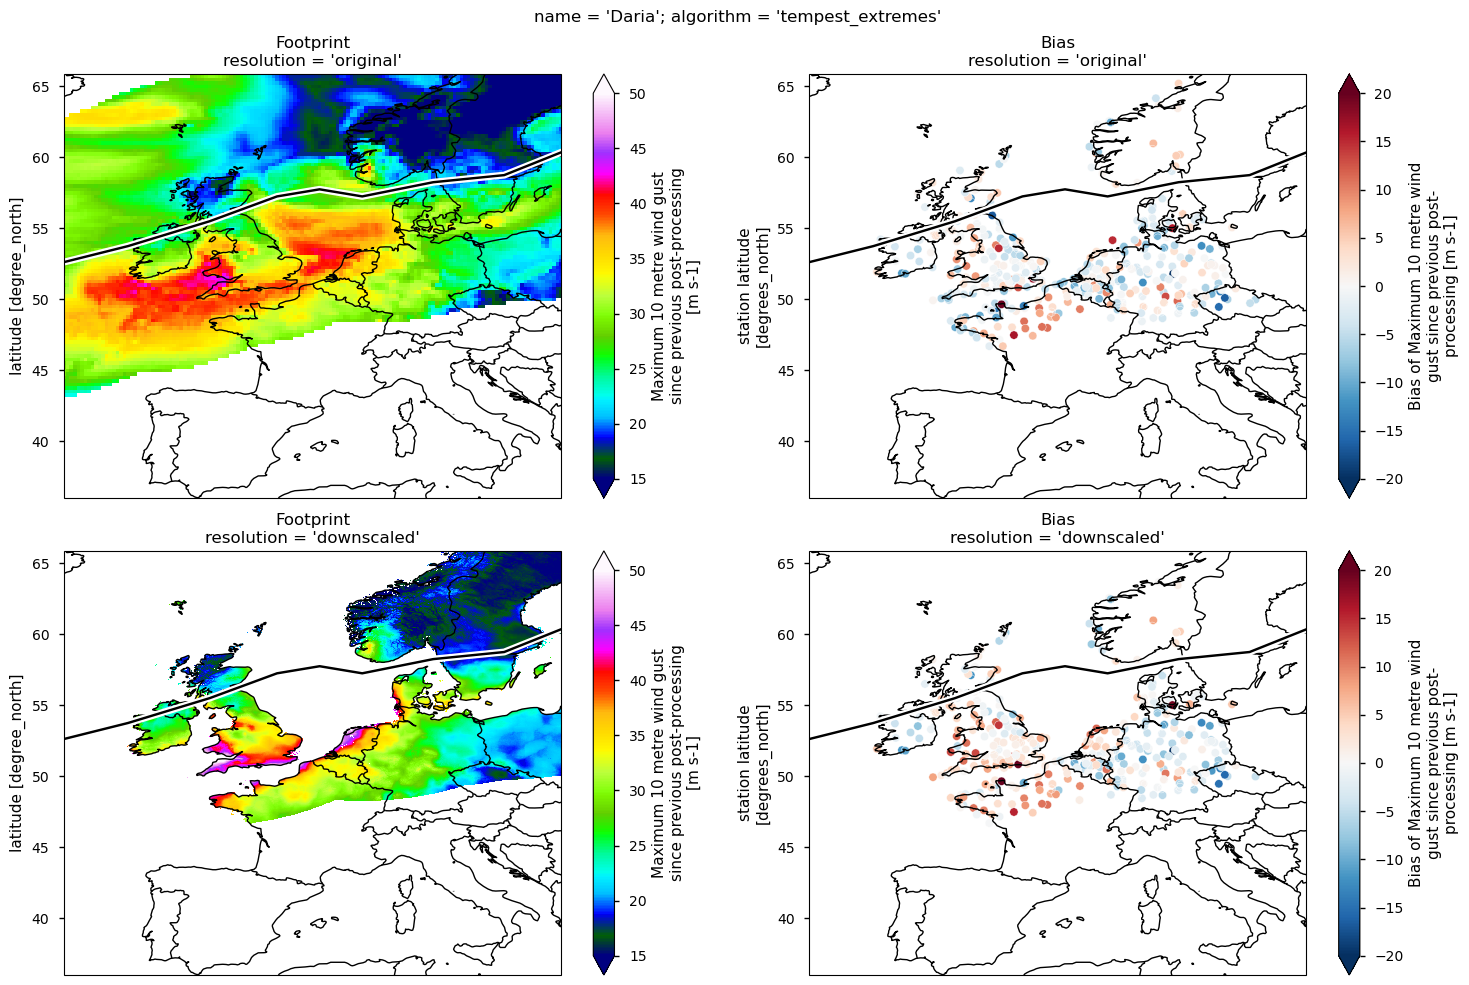

In [19]:
fig, axs = plt.subplots(
    2,
    2,
    subplot_kw={"projection": projection},
    figsize=large_figsize,
)
for i, (resolution, footprint) in enumerate(footprints_for_bias.items()):
    bias = biases[resolution]

    ax = axs[i, 0]
    footprint.plot(
        ax=axs[i, 0],
        **footprint_kwargs,
    )
    ax.set_title(f"Footprint\n{resolution = }")

    ax = axs[i, 1]
    ds = bias.to_dataset().assign_coords(markersize=1)
    ds.plot.scatter(ax=ax, markersize="markersize", **bias_kwargs)
    ax.set_title(f"Bias\n{resolution = }")

for ax in axs.flatten():
    postprocess_ax(ax, track, extent)
fig.suptitle(f"{name = }; {algorithm = }")
fig.tight_layout()

## Step 3: Comparison with all the detected storms

One of the strengths of the EWS dataset is that it provides a comprehensive set of storms detected using a systematic approach with a consistent set of input data. This wide and consistent dataset allows users to perform statistical analysis and put single events into perspective. In the case of storm Daria, the code underlying this use case allows for looping over all the storms detected, with a given algorithm, and computing the mean wind gust over a given region, considering different wind speed thresholds.

The figure below focuses on the UK and provides four different wind speed thresholds, the time series of all storm events that affected the UK (dots). The solid black line represents the annual mean wind speed of storms exceeding a given threshold, and the red dot the event corresponding to storm Daria. This graphical representation shows how the Daria storm stands out compared to the large majority of storms and helps identify events of similar intensity in terms of mean wind speed. 

Here, we focus on a specific NUTS region and compute the mean wind gust over that region for the storm of interest and all the EWS footprints that affected that region. The outputs are shown in Figure 3.

### Download

This function downloads the officicial 2021 NUTS shapes and saves them in the `nuts_path` folder.

In [20]:
def download_nuts(path: Path) -> None:
    if path.exists():
        return None

    url = "https://gisco-services.ec.europa.eu/distribution/v2/nuts/shp/NUTS_RG_20M_2021_4326.shp.zip"
    print(f"Downloading {url}")
    fs = fsspec.filesystem("https")
    fs.get_file(url, path)

In [21]:
# Download the nuts shapefiles
download_nuts(nuts_path)

### Processing

The following functions respectively open the EWS summary indicators to be plotted and compute the mean wind gust of a given footprint over a given region.

In [22]:
# Returns the mask corresponding to a given NUTS region
def open_nuts_region(data_path: str, region: str) -> regionmask.Regions:
    gdf = gpd.read_file(data_path, encoding="latin1")
    return regionmask.from_geopandas(gdf[gdf["NUTS_ID"] == region], names="NUTS_ID")


# Compute the mean wind gust of a given footprint over a given region
def compute_mean_wind_gust(
    footprints: xr.DataArray, indicators: pd.DataFrame, nuts_region: regionmask.Regions
) -> xr.DataArray:
    thresholds = indicators.groupby("threshold")["threshold"].first().to_xarray()
    mask = nuts_region.mask_3D(footprints, drop=False)
    masked_footprints = footprints.where((mask) & (footprints > thresholds))
    weights = np.abs(np.cos(np.deg2rad(masked_footprints["latitude"])))
    result = masked_footprints.weighted(weights).mean(
        ["latitude", "longitude"], keep_attrs=True
    )
    result = result.squeeze("region").to_dataset()
    result["year"] = result["footprint_central_time"].dt.decimal_year
    return result.compute()

This step retrieves the EWS summary indicators, all the original (non-donwscaled) footprints related to a given algorithm and computes the mean wind gust of each footprint over the region of interest.

The yearly mean wind gust speed indicator for the selected region is plotted in Figure 3 as well as the mean wind gust speed of each single event.

In [23]:
indicators = all_indicators[
    (all_indicators["algorithm"] == algorithm) & (all_indicators["region"] == region)
]
footprints = open_footprints(
    c3s_windstorm_path, algorithm, "original", "decontaminated"
)
nuts_region = open_nuts_region(nuts_path, region)
mean_wind_gust = compute_mean_wind_gust(footprints, indicators, nuts_region)

### Figure 3

Figure 3 is made of four plots each focusing on a given wind speed threshold. For each wind speed threshold value three elements are plotted:

- The solid black line represents the annual mean wind speed of storms exceeding a given threshold and affecting the selected region
- The scatter plot in grey shows the the mean wind gust speed for each single EWS footprint exceeding a given threshold and affecting the selected region (only shown when `minimal_download` is set to `False`)
- The red dot shows the storm defined in the initial settings.

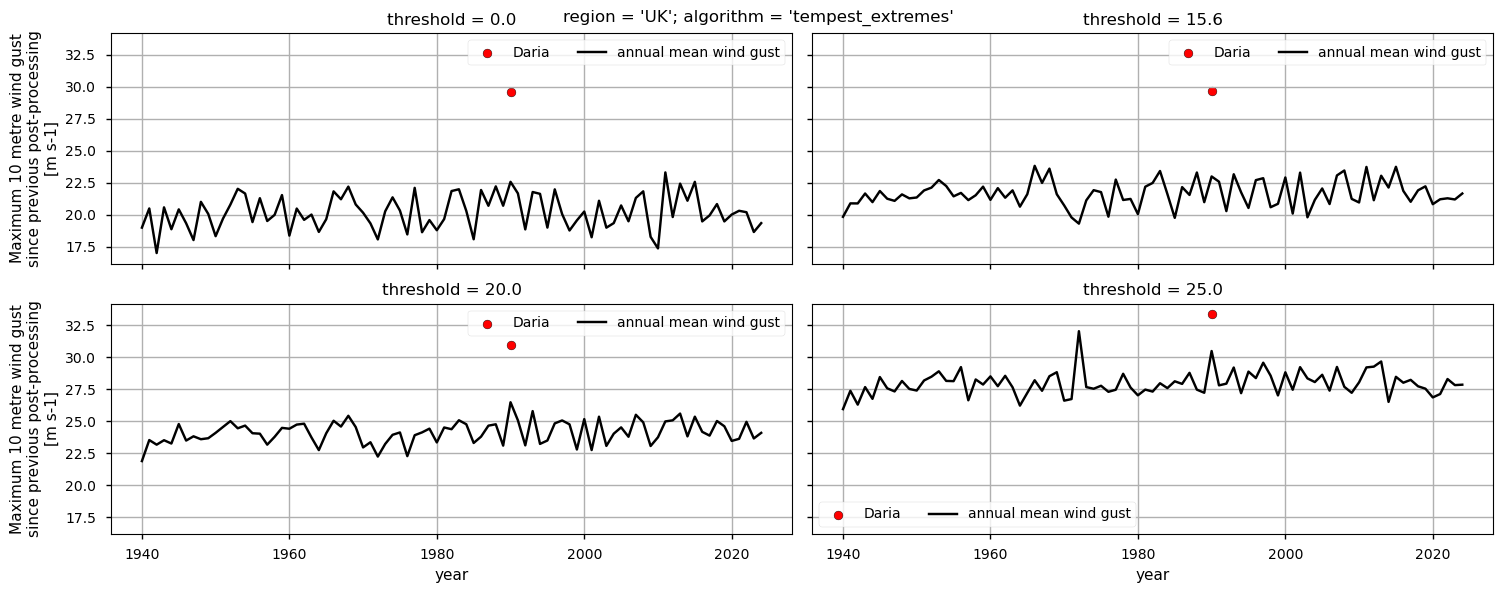

In [24]:
event = mean_wind_gust.sel(track_id=[track_ids[algorithm]])
facet = event.plot.scatter(
    col="threshold",
    col_wrap=2,
    figsize=small_figsize,
    color="red",
    sizes=[40],
    label=name,
    **scatter_kwargs,
)
for ax, sel in zip(facet.axs.flatten(), facet.name_dicts.flatten()):
    threshold = sel["threshold"]
    if not minimal_download:
        all_events = mean_wind_gust.sel(threshold=threshold)
        all_events.plot.scatter(
            ax=ax,
            color=(0, 0, 0, 0.1),
            sizes=[10],
            label="tracks",
            zorder=0,
            **scatter_kwargs,
        )
    df = indicators[indicators["threshold"] == threshold]
    df.plot(
        ax=ax,
        x="year",
        y="mean_wind_gust",
        color="k",
        grid=True,
        label="annual mean wind gust",
        legend=False,
    )
    ax.set_title(f"{threshold = :.1f}")
    ax.legend(ncol=3)
    ax.autoscale()
_ = facet.fig.suptitle(f"{region = }; {algorithm = }")

## Take home messages 📌

This notebook shows how to:

- Identify a specific event within the Enhanced Windstorm Service (EWS) dataset
- Compare the EWS footprints for that specific event with observational data
- Compare the single event to all the storms contained in the EWS dataset and affecting a given region between 1940 to present.